In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from get_model_probabilities import *
from scipy.ndimage import zoom
import scienceplots
plt.style.use(["science","grid"])

Source redshift:1.36


In [4]:
pixelisation_factors = np.array([1, 2, 4,10])


# First get the new thresholds

## Monte carlo each pixelisation

In [ ]:


#target_test_acc = pkl.load(open("pickles/target_test_accuracy.pkl","rb"))

ifilter='concat'
all_models =  glob(f"../models/concat/cdan_baha2dark_pre_squeezenet1_aw_1_pad_shear_avgpool_gauss_seed_*_nob1_ft_tweaked_align_10_best.pth")

#get the fiducial resolution results
fiducial_name = f"pickles/all_models_{ifilter}_nz_results.pkl"
fid_res_results = pkl.load(open(fiducial_name,'rb'))

#now do the rest
output_name = f"pickles/resolution_dep_results.pkl"

if os.path.isfile(output_name):
    all_results = pkl.load(open(output_name,'rb'))
else:
    all_results = {}
    all_results[20] = {
        k: v['src']
        for k, v in fid_res_results.items()
    }


domain = {
        'tgt':'darkskies_obs',
        'src':'bahamas_obs'
        }    
for pixelisation in pixelisation_factors:
    
    resolution = int(20*pixelisation)
    
    args.image_size = 100//pixelisation
    
    
    if not resolution in all_results.keys():
        all_results[resolution] = {}
        
    for imodel in tqdm(all_models):

        seed = imodel.split('_')[-7]

        args.jwst_filter = ifilter
        args.apply_intrinsic_ell = 1.
        args.verbose=False
        args.train_split =0.05
        zs = {
        'f115w':1.6,
        'f150w':1.65,
        'concat':1.65
        }
        args.ignore_dataset = [''] # Although i ignored during training i want to see duringn testing.

        if f"seed_{seed}" not in all_results[resolution].keys():

            all_results[resolution][f"seed_{seed}"]  = []
            

        args.unbalance = True
        args.verbose = False
        for i in range(len( all_results[resolution][f"seed_{seed}"]), imonte):
            args.zs = zs[ifilter]

            for idomain in domain.keys():

                target_domain = domain[idomain]

                results = get_probabilities( 
                        target_domain,
                        [imodel],
                        args,
                        quiet=True
                )
                del results['data_loaders']

                all_results[resolution][f"seed_{seed}"].append( results )

            pkl.dump(all_results, open(output_name,"wb"))

        

  0%|                                                    | 0/30 [00:00<?, ?it/s]


NameError: name 'imonte' is not defined

## Now get the thresholds

In [10]:
thresholds = pkl.load(open(output_name,'rb'))
output_name = f"pickles/resolution_dep_results.pkl"

#get the fiducial resolution results
fiducial_name = f"pickles/all_models_{ifilter}_nz_results.pkl"
fid_res_results = pkl.load(open(fiducial_name,'rb'))
thresholds[20] = {
        k: v['src']
        for k, v in fid_res_results.items()
    }

tgtresults = {}
srcresults = {}

correction = 2.
for ikx, ikey in enumerate(thresholds.keys()):
    
    all_results = thresholds[ikey]
    
    


    for itgt in range(2):
        all_thresholds = []
        for imodel in all_results.keys():

            seed = float(imodel.split('_')[1])                


            tgt = get_threshold_for_cross( 
                [ all_results[imodel][i*2+itgt] for i in range(len(all_results[imodel])//2) ], 
                quiet=False)

            all_thresholds.append(tgt['thresholds'])

        all_thresholds = np.array(all_thresholds)
        means = 1-np.nanmean(all_thresholds,axis=0)
        errors = np.std(all_thresholds,axis=0) / all_thresholds.shape[0]**0.38*correction
            
        if itgt == 0:
            srcresults[ikey] = [ tgt['cross_sections'], means, errors]
        else:
            tgtresults[ikey] = [ tgt['cross_sections'], means, errors]


# Pixelise the actual data

In [ ]:
if os.path.isfile( "pickles/model_on_data_pixelisation.pkl" ):
    models, probabilities, probabilities_noise =  pkl.load(open("pickles/model_on_data_pixelisation.pkl","rb"))
    #raise SystemExit
imonte=10

ifilter = 'concat'


outfile = f"../data/100/a2744/obs_data_{ifilter}_pixelisation.pkl"
obs_data = get_obs_data( ifilter, data_dir="../data/100/a2744/")

fid_e1, fid_e2 = bin_obs_data( obs_data )

e1_stacked = [fid_e1]
e2_stacked = [fid_e2]
ngalaxies = []

for pixelisation in pixelisation_factors:
    
    new_data = obs_data.copy()
        
    npix = fid_e1.shape[0]//pixelisation

    pix_e1, pix_e2 = bin_obs_data( new_data, npix=npix)
    
    new_e1 = zoom( pix_e1, pixelisation)
    new_e2 = zoom( pix_e2, pixelisation)

    e1_stacked.append( new_e1 )
    e2_stacked.append( new_e2 )
    
    ngalaxies.append(new_data.shape[0])
 
e1_stacked = np.array(e1_stacked)
e2_stacked = np.array(e2_stacked)

stacked = np.append(e1_stacked[None,:,:,:], e2_stacked[None,:,:,:], axis=0)
stacked = np.moveaxis( stacked, 0, 1)
ngalaxies = np.array(ngalaxies)

pkl.dump([{}, stacked],open(outfile,"wb"))


#RUN ALL MODELS ON THE TEST DATA
#-------------------------------
args.source_domain='a2744'
args.target_domain='a2744'

models = {}
probabilities = {}
probabilities_noise = {}

    
    
cdan_models = np.sort(glob(
    f"../models/{ifilter}/cdan_baha2dark_pre_squeezenet1_aw_1_pad_shear_avgpool_gauss_seed_*_nob1_ft_tweaked_align_10_best.pth"
))
all_models = []
for imodel in cdan_models:
    args.checkpoint = imodel
    this_model = create_model(args)

    model_name = f"seed_{this_model.args.seed}"
    #if target_test_accuracy[ifilter][model_name]['target_test_f1'] <0.48:
    #    continue

    all_models.append(this_model)
print(f"Found {len(all_models)} Models")
models[ifilter] = all_models
meta, data = pkl.load(open(outfile,"rb"))

#repeat 
probabilities_filt = []
probabilities_noise_filt = []

with torch.no_grad():

    for imodel in tqdm(all_models):
        outputs_dict = imodel([torch.tensor(data,dtype=torch.float32)])
        #if torch.all(torch.abs(outputs_dict['classification'][:,0] - outputs_dict['classification'][0,0])  < 0.01):
        #   continue
        probabilities_filt.append(torch.softmax( outputs_dict['classification'], dim=1 )[0,0]) 
        probabilities_noise_filt.append(torch.softmax( outputs_dict['classification'], dim=1 )[1:,0])


probabilities_filt = torch.tensor( probabilities_filt).detach().numpy()
probabilities_noise_filt =  torch.stack( probabilities_noise_filt).detach().numpy()


probabilities[ifilter] = probabilities_filt
probabilities_noise[ifilter] = probabilities_noise_filt
pkl.dump([models, probabilities, probabilities_noise], open("pickles/model_on_data_pixelisation.pkl","wb"))

Found 30 Models


100%|███████████████████████████████████████████| 30/30 [00:00<00:00, 79.31it/s]


NameError: name 'tgtresults' is not defined

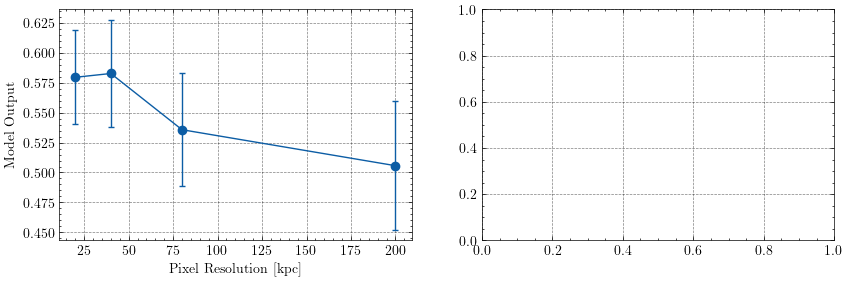

In [5]:
fig,axarr = plt.subplots(1,2,figsize=(10,3))

ax = axarr[0]
models, probabilities, probabilities_noise = pkl.load( open("pickles/model_on_data_pixelisation.pkl","rb") )
ifilter = 'concat'
means =  np.mean(probabilities_noise[ifilter],axis=0)
errors =  np.std(probabilities_noise[ifilter],axis=0)

ax.errorbar( 20.*pixelisation_factors, 1-means, errors, capsize=2, fmt='o-')

ax.set_xlabel("Pixel Resolution [kpc]")  
ax.set_ylabel("Model Output")

ax = axarr[1]

for iresult in tgtresults.keys():
    ax.plot(
        tgtresults[iresult][0]+1e-3,
        tgtresults[iresult][1]-tgtresults[iresult][1][0] + tgtresults[20][1][0],
        'o-',label=f"{iresult}kpc")
    #ax.errorbar(
    #    srcresults[iresult][0],
    #    srcresults[iresult][1]-srcresults[iresult][1][0] + srcresults[20][1][0],
    #    srcresults[iresult][2], fmt='o', capsize=2)
ax.set_xlabel("Self-Interaction Cross-Section [cm$^2$/g]")
ax.set_ylabel("Model Output")
ax.set_xscale('log')
ax.legend(title='Pixel Resolution')
fig.align_xlabels()

In [6]:
probabilities_noise[ifilter].shape

(30, 4)